# Recap:
* Numpy Linear Algebra Library: `numpy.linalg`

# Today's agenda:
* Another useful Python library: Scipy

# 1. 1D Interpolation using `la.solve`

**Recall Lecture 34:** Given two points $(x_1,y_1)$ and $(x_2,y_2)$, can you have a line $y = f(x)$ passing throught these two points?

* Equation of a line:
$$ y = a_1+a_2 x$$

* We want this to hold for both points, so we have a system:
$$\begin{aligned}
&y_1 = a_1+a_2x_1\\
&y_2 = a_1+a_2x_2
\end{aligned}$$

  - $a_1$ and $a_2$ are the unknowns
  - $x_1,y_1,x_2,y_2$ are known.
  - Task: solving for $a_1$ and $a_2$.

* Strategy for rearranging in matrix form:
  - Collect all unknowns on the left hand side;
  - Collect all knowns on the right side;
  - Coeffients in front of the unknowns go in the matrix $\mathbf A$;
  - Unknowns go into a vector $\mathbf u$
  - Knowns go into another vector $\mathbf b$.
  $$\begin{aligned}
&y_1 = a_1+a_2x_1\\
&y_2 = a_1+a_2x_2
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&x_1\\
1&x_2
\end{bmatrix}}_{\mathbf A}\underbrace{\begin{bmatrix}
a_1\\
a_2
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
y_1\\
y_2
\end{bmatrix}}_{\mathbf b}$$

* Recall Lecture 33: `numpy.linalg.solve`:
`u = la.solve(A, b)`

Example:

In [ ]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

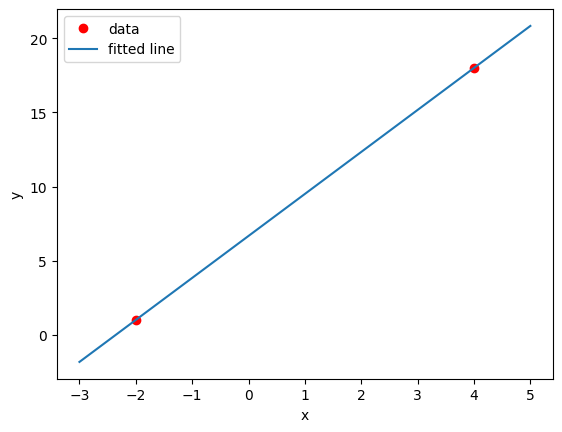

In [ ]:
# given two points:
x1 = -2
y1 = 1
x2 = 4
y2 = 18
# form matrix
A = np.array([[1, x1], [1, x2]])
# form vector
b = np.array([y1, y2])
# solve for u
u = la.solve(A, b)
a1 = u[0]
a2 = u[1]
x_fine = np.linspace(-3, 5, 100)
y_fine = a1 + a2 * x_fine
# plot the data and the fitted line
plt.plot([x1,x2], [y1,y2], "ro", label="data")
plt.plot(x_fine, y_fine, label="fitted line")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Now given three points $(x_1,y_1)$, $(x_2,y_2)$ and $(x_3,y_3)$, they are likely not in a line. But can you find a parabola $y = f(x)$ that passes through these three points?

* Equation of a parabola:
$$ y = a_1+a_2 x+a_3x^2$$

* We want this to hold for all points, so we have a system:
$$\begin{aligned}
&y_1 = a_1+a_2x_1+a_3x_1^2\\
&y_2 = a_1+a_2x_2+a_3x_2^2\\
&y_3 = a_1+a_2x_3+a_3x_3^2
\end{aligned}$$

  - $a_1,a_2$ and $a_3$ are the unknowns
  - $x_1,y_1,x_2,y_2,x_3,y_3$ are known.
  - Task: solving for $a_1,a_2$ and $a_3$.

* Strategy for rearranging in matrix form:
  - Collect all unknowns on the left hand side;
  - Collect all knowns on the right side;
  - Coeffients in front of the unknowns go in the matrix $\mathbf A$;
  - Unknowns go into a vector $\mathbf u$
  - Knowns go into another vector $\mathbf b$.
  $$\begin{aligned}
&y_1 = a_1+a_2x_1+a_3x_1^2\\
&y_2 = a_1+a_2x_2+a_3x_2^2\\
&y_3 = a_1+a_2x_3+a_3x_3^2
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&x_1&x_1^2\\
1&x_2&x_2^2\\
1&x_3&x_3^2
\end{bmatrix}}_{\mathbf A}\underbrace{\begin{bmatrix}
a_1\\
a_2\\
a_3
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
y_1\\
y_2\\
y_3
\end{bmatrix}}_{\mathbf b}$$

* Recall Lecture 33: `numpy.linalg.solve`:
`u = la.solve(A, b)`

Example:

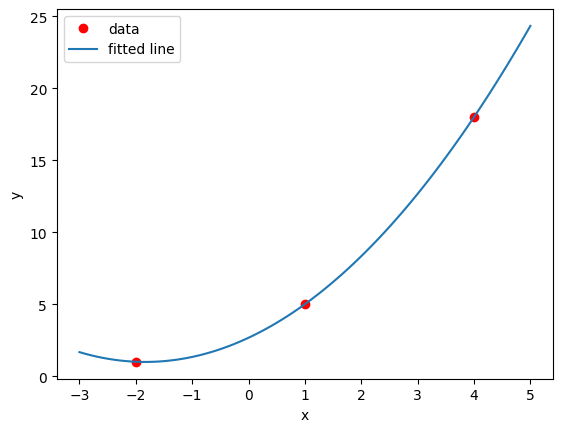

In [ ]:
# given two points:
x1 = -2
y1 = 1
x2 = 1
y2 = 5
x3 = 4
y3 = 18
# form matrix
A = np.array([[1, x1,x1**2], [1, x2,x2**2],[1,x3,x3**2]])
# form vector
b = np.array([y1, y2,y3])
# solve for u
u = la.solve(A, b)
a1 = u[0]
a2 = u[1]
a3 = u[2]
x_fine = np.linspace(-3, 5, 100)
y_fine = a1 + a2 * x_fine + a3 * x_fine**2
# plot the data and the fitted line
plt.plot([x1,x2,x3], [y1,y2,y3], "ro", label="data")
plt.plot(x_fine, y_fine, label="fitted line")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Now we can generalize to $n$ points--given $n$ points $(x_1,y_1),(x_2,y_2)\cdots (x_n,y_n)$, you can find a polynomial of degree $n$ $y = f(x)$ that passes through all these points.

* Equation of a polynomial of degree $n$:
$$ y = a_1+a_2 x+a_3x^2+\cdots + a_nx^{n-1}$$

* We want this to hold for all points, so we have a system:
  $$\begin{aligned}
&y_1 = a_1+a_2x_1+\cdots +a_nx_1^{n-1}\\
&y_2 = a_1+a_2x_2+\cdots + a_nx_2^{n-1}\\
&\cdots\\
&y_n = a_1+a_2x_n+\cdots + a_nx_n^{n-1}
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&x_1&x_1^2&\cdots&x_1^{n-1}\\
1&x_2&x_2^2&\cdots&x_1^{n-1}\\
\cdots\\
1&x_n&x_n^2&\cdots&x_n^{n-1}
\end{bmatrix}}_{\mathbf A}\underbrace{\begin{bmatrix}
a_1\\
a_2\\
\vdots\\
a_n
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}}_{\mathbf b}$$

* `u = la.solve(A, b)`

## **interpolating using high-order polynomials is often a bad idea**

# 2. 1D Interpolation using `scipy.interpolate`

In [ ]:
import scipy.interpolate as interp

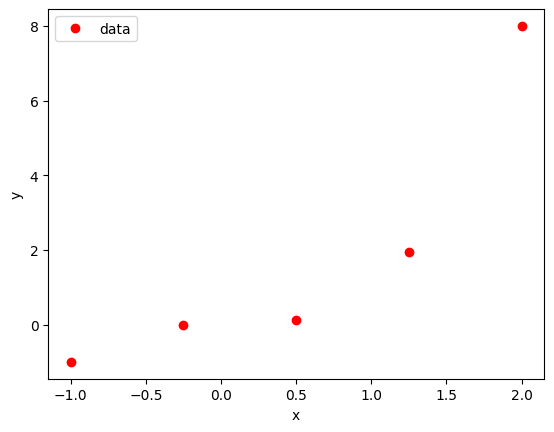

In [ ]:
x = np.linspace(-1, 2, 5)
y = x**3
plt.plot(x, y, "ro",label = 'data')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
?interp.interp1d

In [ ]:
# estimate the linear piece-wise functions
# meaning for each nearby two points, find a line passing through as before.
f = interp.interp1d(x, y, kind="linear")

In [ ]:
# f is an interpolator
f

In [ ]:
# you can access the data points by
print(f.x)
print(f.y)

[-1.   -0.25  0.5   1.25  2.  ]
[-1.       -0.015625  0.125     1.953125  8.      ]


In [ ]:
# you can also evaluate other points value in the regime, in this case between -1 and 2
f(1)

array(1.34375)

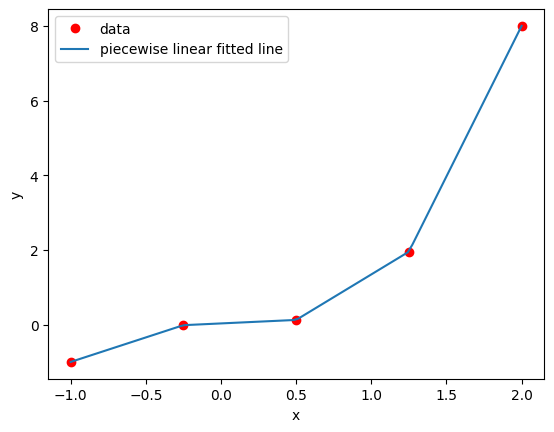

In [ ]:
x_fine = np.linspace(-1, 2, 100)
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine, f(x_fine),label = 'piecewise linear fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
f(1)

array(1.34375)

In [ ]:
f(3)
## error: out of the interpolation range. f is only valid in interpolation regime by default

ValueError: A value (3.0) in x_new is above the interpolation range's maximum value (2.0).

In [ ]:
f = interp.interp1d(x, y, kind="linear", fill_value="extrapolate") # allows for extrapolation
# estimate the linear piece-wise functions
f(3)

array(16.0625)

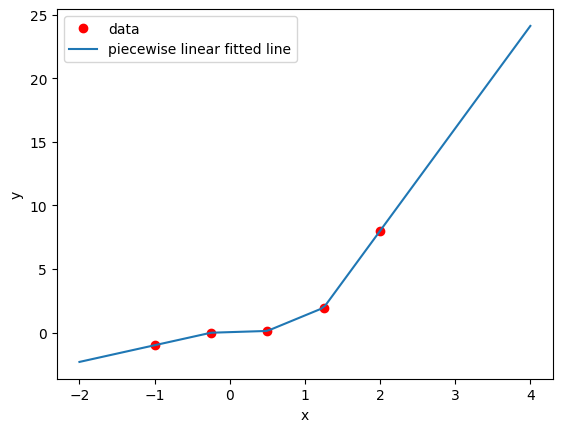

In [ ]:
x_fine = np.linspace(-2, 4, 100)
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine, f(x_fine),label = 'piecewise linear fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

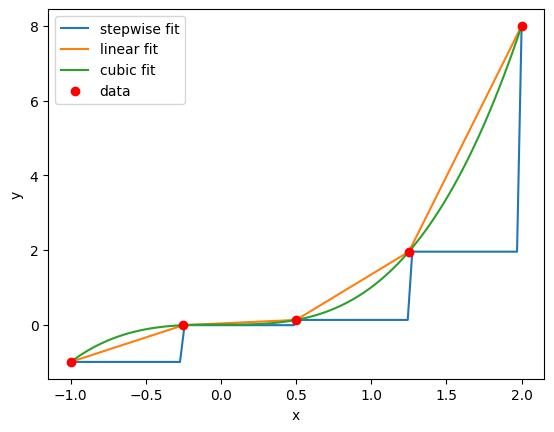

In [ ]:
x_fine = np.linspace(-1, 2, 100)
plt.plot(x_fine,interp.interp1d(x,y,kind="zero")(x_fine)) #stepwise fit
plt.plot(x_fine,interp.interp1d(x,y,kind="linear")(x_fine)) #best linear fit
plt.plot(x_fine, interp.interp1d(x, y, kind="cubic")(x_fine))  # best fit curve (we kind of know)
plt.plot(x, y, "ro")
plt.legend(["stepwise fit", "linear fit", "cubic fit", "data"])
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 3. 1D Curve fitting



## 3.1 Issues with interpolation using high-order polynomials

Given $n$ points $(x_1,y_1),(x_2,y_2)\cdots (x_n,y_n)$, we said that **interpolating using high-order polynomials is often a bad idea**. Let's see why

### Example 1 : Runge's Phenomenon for clean data

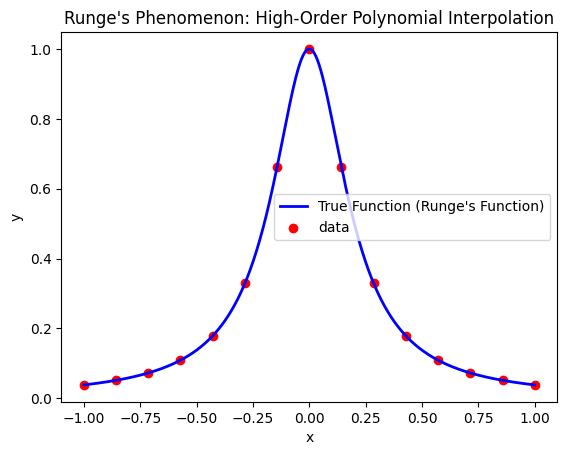

In [ ]:
# Define the Runge function
def runge_function(x):
    return 1 / (1 + 25 * x**2)

# Define the interval and the true function
x_true = np.linspace(-1, 1, 1000)
y_true = runge_function(x_true)

# Number of  data points
n_points = 15
x_interp = np.linspace(-1, 1, n_points)
y_interp = runge_function(x_interp)


# Plot the results
plt.plot(x_true, y_true, label="True Function (Runge's Function)", linewidth=2, color="blue")
plt.scatter(x_interp, y_interp, color="red", label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge's Phenomenon: High-Order Polynomial Interpolation")
plt.legend()
plt.show()

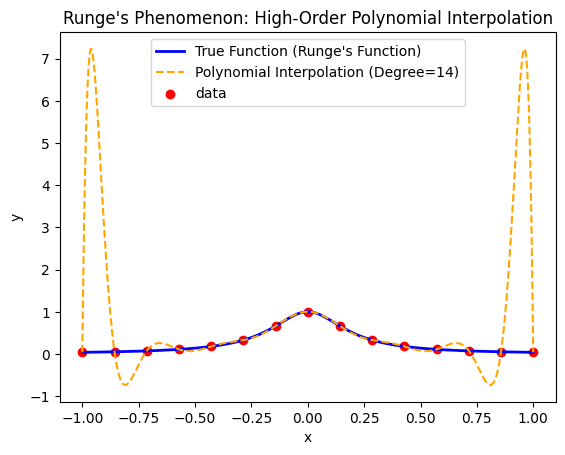

In [ ]:
# Fit a high-order polynomial (degree = n_points - 1)
coefficients = np.polyfit(x_interp, y_interp, n_points - 1)
poly = np.poly1d(coefficients)

# Evaluate the polynomial
y_poly = poly(x_true)

# Plot the results
plt.plot(x_true, y_true, label="True Function (Runge's Function)", linewidth=2, color="blue")
plt.plot(x_true, y_poly, label=f"Polynomial Interpolation (Degree={n_points - 1})", linestyle="--", color="orange")
plt.scatter(x_interp, y_interp, color="red", label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge's Phenomenon: High-Order Polynomial Interpolation")
plt.legend()
plt.show()

### Example 2: Polynomial fitting for noisy data

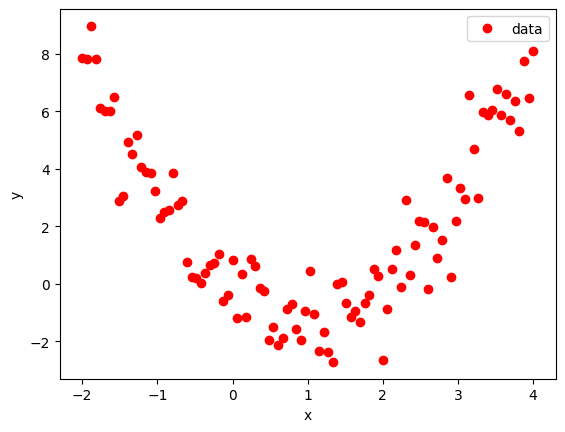

In [ ]:
x = np.linspace(-2, 4, 100)
y = -2*x + x**2 + np.random.randn(100)
plt.plot(x, y, "ro",label = 'data')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

/tmp/ipykernel_2390/4032236408.py:1: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x, y, 100-1)


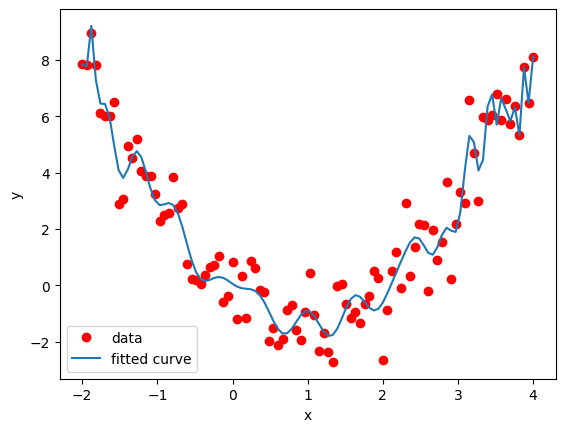

In [ ]:
coefficients = np.polyfit(x, y, 100-1)
poly = np.poly1d(coefficients)
x_fine = np.linspace(-2, 4, 100)
y_fine = poly(x_fine)

plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine, y_fine,label = 'fitted curve')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 3.2 Least squares data fitting

Given $n$ points $(x_1,y_1),(x_2,y_2)\cdots (x_n,y_n)$, we can still first try to fit a line to the data

* Equation of a line:
$$ y = a_1+a_2 x$$

* We want this to hold for all $n$ points, so we have a system:
$$\begin{aligned}
&y_1 = a_1+a_2x_1\\
&y_2 = a_1+a_2x_2\\
&\cdots\\
&y_n = a_1 +a_2x_n
\end{aligned}$$

  - $a_1$ and $a_2$ are the unknowns
  - $x_1,y_1,x_2,y_2,\cdots, x_n,y_n$ are known.
  - Task: solving for $a_1$ and $a_2$.

* Strategy for rearranging in matrix form:
  - Collect all unknowns on the left hand side;
  - Collect all knowns on the right side;
  - Coeffients in front of the unknowns go in the matrix $\mathbf A$;
  - Unknowns go into a vector $\mathbf u$
  - Knowns go into another vector $\mathbf b$.
  $$\begin{aligned}
&y_1 = a_1+a_2x_1\\
&y_2 = a_1+a_2x_2\\
&\cdots\\
&y_n = a_1 +a_2x_n
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&x_1\\
1&x_2\\
\cdots\\
1&x_n
\end{bmatrix}}_{\mathbf A}\underbrace{\begin{bmatrix}
a_1\\
a_2
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}}_{\mathbf b}$$

* Recall Lecture 33: `numpy.linalg.lstsq`:
`u = la.lstsq(A, b)` solves $\arg\min_{\mathbf u} \|\mathbf A\mathbf u-\mathbf b\|_2$

[np.float64(1.980189646540331), np.float64(0.010535657418938155)]


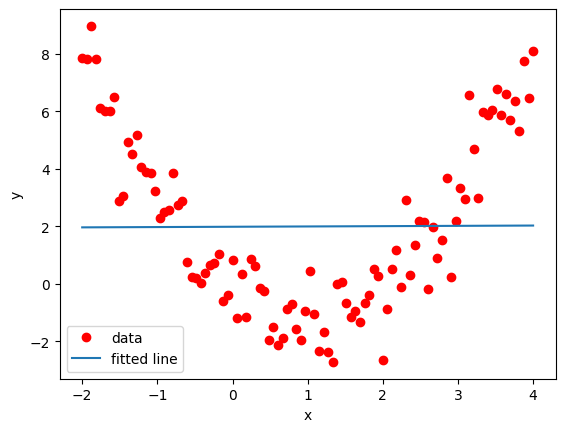

In [ ]:
A = np.ones((100,2))
A[:,1] = x
b = y
u,_,_,_ = la.lstsq(A, b)
a1 = u[0]
a2 = u[1]
print([a1,a2])
x_fine = np.linspace(-2, 4, 100)
y_fine = a1 + a2 * x_fine
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine,y_fine ,label = 'fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Looks like it's a bad fitting. We can try to fit a parabola to the data

* Equation of a parabola:
$$ y = a_1+a_2 x +a_3x^2$$

* We want this to hold for all $n$ points, so we have a system:
$$\begin{aligned}
&y_1 = a_1+a_2x_1+a_3x_1^2\\
&y_2 = a_1+a_2x_2+a_3x_2^2\\
&\cdots\\
&y_n = a_1 +a_2x_n+a_3x_n^2
\end{aligned}$$

  - $a_1,a_2$ and $a_3$ are the unknowns
  - $x_1,y_1,x_2,y_2,\cdots, x_n,y_n$ are known.
  - Task: solving for $a_1,a_2$ and $a_3$.


  $$\begin{aligned}
&y_1 = a_1+a_2x_1+a_3x_1^2\\
&y_2 = a_1+a_2x_2+a_3x_2^2\\
&\cdots\\
&y_n = a_1 +a_2x_n+a_3x_n^2
\end{aligned}\Rightarrow \underbrace{\begin{bmatrix}
1&x_1&x_1^2\\
1&x_2&x_2^2\\
\cdots\\
1&x_n&x_3^2
\end{bmatrix}}_{\mathbf A}\underbrace{\begin{bmatrix}
a_1\\
a_2\\
a_3
\end{bmatrix}}_{\mathbf u} = \underbrace{\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}}_{\mathbf b}$$

* `u = la.lstsq(A, b)` solves $\arg\min_{\mathbf u} \|\mathbf A\mathbf u-\mathbf b\|_2$

In [ ]:
help(la.lstsq)

Help on _ArrayFunctionDispatcher in module numpy.linalg:

lstsq(a, b, rcond=None)
    Return the least-squares solution to a linear matrix equation.

    Computes the vector `x` that approximately solves the equation
    ``a @ x = b``. The equation may be under-, well-, or over-determined
    (i.e., the number of linearly independent rows of `a` can be less than,
    equal to, or greater than its number of linearly independent columns).
    If `a` is square and of full rank, then `x` (but for round-off error)
    is the "exact" solution of the equation. Else, `x` minimizes the
    Euclidean 2-norm :math:`||b - ax||`. If there are multiple minimizing
    solutions, the one with the smallest 2-norm :math:`||x||` is returned.

    Parameters
    ----------
    a : (M, N) array_like
        "Coefficient" matrix.
    b : {(M,), (M, K)} array_like
        Ordinate or "dependent variable" values. If `b` is two-dimensional,
        the least-squares solution is calculated for each of the `K` c

[np.float64(-0.1758612039340747), np.float64(-2.082101932747396), np.float64(1.046318795083168)]


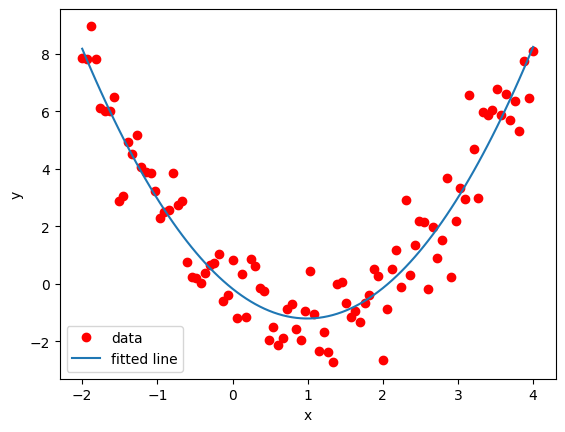

In [ ]:
A = np.ones((100,3))
A[:,1] = x
A[:,2] = x**2
b = y
u,_,_,_ = la.lstsq(A, b)
a1 = u[0]
a2 = u[1]
a3 = u[2]
print([a1,a2,a3])
x_fine = np.linspace(-2, 4, 100)
y_fine = a1 + a2 * x_fine +a3 * x_fine**2
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine,y_fine ,label = 'fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Pretty good and even better than higher order polynomial fitting (we lind of expect it as we know the data was generated from adding noise to a parabola function)

## 3.3 `scipy.optimize.curve_fit`

The above procedure can be easily implemented in `scipy.optimize.curve_fit`

In [ ]:
from scipy import optimize

In [ ]:
?optimize.curve_fit

In [ ]:
# let's take a guess
def f(x, a1, a2):
    return a1  + a2*x

In [ ]:
((a1, a2), _) = optimize.curve_fit(f = f,
                                 xdata = x,
                                 ydata = y,
                                  p0 = (0, 1))#init gues
a1, a2

(np.float64(1.980189646669434), np.float64(0.010535656958089334))

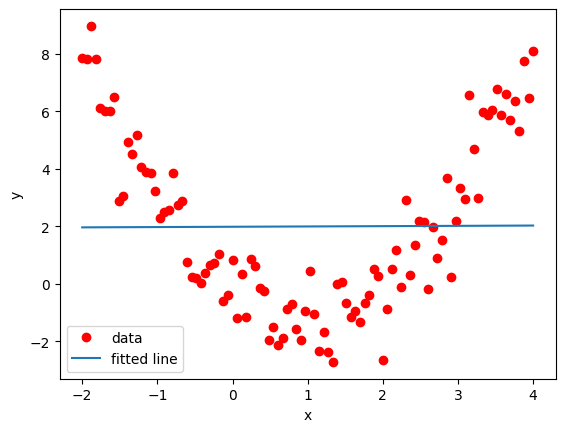

In [ ]:
x_fine = np.linspace(-2, 4, 100)
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine,f(x_fine, a1, a2) ,label = 'fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
# Similar for parabola
def g(x, a1, a2, a3):
    return a1+a2 * x + a3 * x**2

In [ ]:
# initial guess may affect the results
((a1, a2, a3), _) = optimize.curve_fit(g, x, y, (1.5, 0, 7))
a1, a2, a3

(np.float64(-0.17586127062926696),
 np.float64(-2.0821019405896233),
 np.float64(1.0463188046147387))

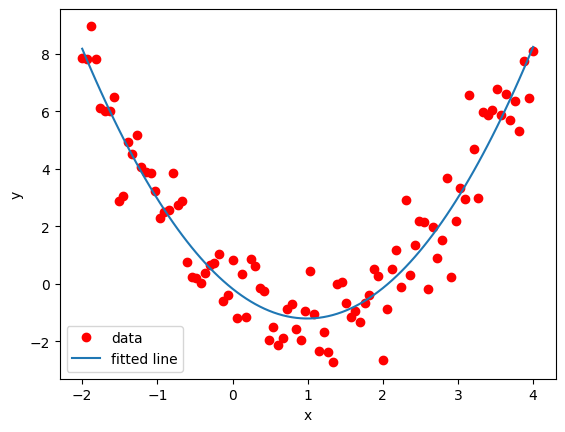

In [ ]:
x_fine = np.linspace(-2, 4, 100)
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine,g(x_fine, a1, a2,a3) ,label = 'fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
# Let's try higher order
def h(x, a1, a2, a3):
    return a1+a2 * np.sin(a3*x)

# initial guess may affect the results
((a1, a2, a3), _) = optimize.curve_fit(h, x, y, (1.5, -5, 1))
a1, a2, a3

(np.float64(1.588036175352583),
 np.float64(-3.4511499612174914),
 np.float64(1.1920692267157538))

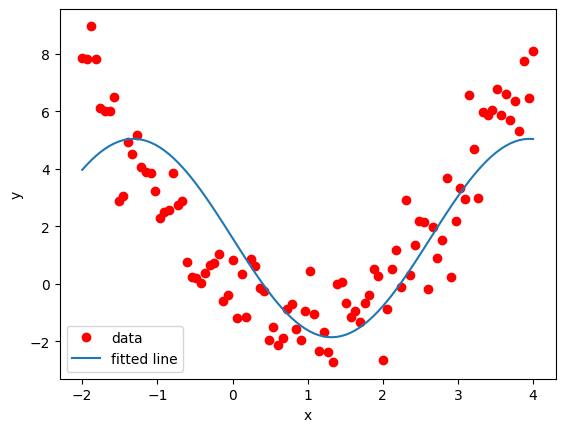

In [ ]:
x_fine = np.linspace(-2, 4, 100)
plt.plot(x, y, "ro",label = 'data')
plt.plot(x_fine,h(x_fine, a1, a2,a3) ,label = 'fitted line')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Question: What model should we choose?

More advanced topic in scientific computing: **model selection** is the process of choosing the best model from a set of candidate models based on their performance. It involves comparing models to determine which one best balances complexity and predictive power for a given dataset.

We already see that the model with higher complexity does NOT necessarily have better fitting (e.g., Runge's phonomena)